# Bài Toán 1: Phân tích trạng thái thị trường (Market Regime Discovery)
**Research Question:** So sánh GMM, HMM, HDBSCAN với KMeans baseline trong bài toán market regime discovery và transition dynamics.

**Kết quả::**
Nghiên cứu này giúp xác định "Dynamics" (động lực) của thị trường, giúp nhà đầu tư biết họ đang ở trong môi trường rủi ro cao hay thấp.


### Thiết lập môi trường
- `hmmlearn`: Thư viện chuyên dụng cho mô hình Markov ẩn.
- `hdbscan`: Thuật toán phân cụm dựa trên mật độ để phát hiện nhiễu.
- `RobustScaler`: Chuẩn hóa dữ liệu bằng cách sử dụng trung vị và khoảng tứ phân vị, giúp chống lại các giá trị ngoại lai (outliers) cực đoan trong crypto.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import zscore

# Sklearn
from sklearn.preprocessing import RobustScaler
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA

# HMM
from hmmlearn import hmm

# HDBSCAN
import hdbscan

# NetworkX
import networkx as nx

sns.set_theme(style='whitegrid')
plt.rcParams.update({'figure.figsize':(12,5),'axes.titlesize':13,'axes.labelsize':11})
RANDOM_STATE = 42
print('All imports OK')


All imports OK


### Load và Làm sạch dữ liệu
- Dữ liệu được nạp từ file CSV với khung thời gian 1h.
- `interpolate(method='time')`: Xử lý các nến bị thiếu bằng cách nội suy thời gian, đảm bảo chuỗi thời gian không bị ngắt quãng trước khi tính toán các chỉ báo kỹ thuật.


In [2]:
# ── Load data ───────────────────────────────────────────────────────────────
try:
    df = pd.read_csv('/content/btc_ohlcv_1h.csv')
except FileNotFoundError:
    df = pd.read_csv('D:/DataMining/sgu-2026-datamining-timeseries/Data/btc_ohlcv_1h.csv')

df.columns = [c.strip().lower() for c in df.columns]
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.sort_values('date').set_index('date')
if df.isna().sum().sum() > 0:
    df = df.interpolate(method='time').ffill().bfill()
print(f'Loaded: {len(df)} rows | {df.index.min()} → {df.index.max()}')


Loaded: 13263 rows | 2024-10-01 00:00:00 → 2026-04-06 14:00:00


### Kỹ thuật đặc trưng (Feature Engineering)
- **log_ret**: Sử dụng lợi nhuận log thay vì giá để đạt tính dừng (stationarity).
- **volatility**: Độ biến động 24h, đại diện cho rủi ro thị trường.
- **ATR (Average True Range)**: Đo lường độ co giãn của giá (volatility tuyệt đối).
- **vol_z**: Volume Z-Score để phát hiện các đột biến khối lượng thường đi kèm với việc đổi trạng thái (regime shift).
- **bb_width**: Độ rộng dải Bollinger, phản ánh thị trường đang 'nén' hay 'giãn'.


In [3]:
# ── Feature Engineering ─────────────────────────────────────────────────────
WINDOW = {'vol':24,'mom':12,'atr':14,'volz':24}

df['ret']        = df['close'].pct_change()
df['log_ret']    = np.log(df['close']/df['close'].shift(1))
df['volatility'] = df['log_ret'].rolling(WINDOW['vol']).std() * np.sqrt(WINDOW['vol'])
df['momentum']   = df['close'].pct_change(periods=WINDOW['mom'])

hl = df['high']-df['low']
hc = (df['high']-df['close'].shift(1)).abs()
lc = (df['low'] -df['close'].shift(1)).abs()
df['atr'] = pd.concat([hl,hc,lc],axis=1).max(axis=1).rolling(WINDOW['atr']).mean()

df['vol_change'] = df['volume'].pct_change()
vm = df['volume'].rolling(WINDOW['volz']).mean()
vs = df['volume'].rolling(WINDOW['volz']).std()
df['vol_z'] = (df['volume']-vm)/(vs+1e-9)

delta = df['close'].diff()
g = delta.where(delta>0,0).rolling(14).mean()
l = (-delta.where(delta<0,0)).rolling(14).mean()
df['rsi'] = 100 - 100/(1+g/(l+1e-9))

ema12 = df['close'].ewm(span=12,adjust=False).mean()
ema26 = df['close'].ewm(span=26,adjust=False).mean()
df['macd'] = ema12-ema26

ma20  = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()
df['bb_width'] = (2*std20)/(ma20+1e-9)

df = df.dropna()

FEATURE_COLS = ['ret','log_ret','volatility','momentum','atr',
                'vol_change','vol_z','rsi','macd','bb_width']

scaler = RobustScaler()
X = scaler.fit_transform(df[FEATURE_COLS])
print(f'Feature matrix: {X.shape} | Features: {FEATURE_COLS}')


Feature matrix: (13239, 10) | Features: ['ret', 'log_ret', 'volatility', 'momentum', 'atr', 'vol_change', 'vol_z', 'rsi', 'macd', 'bb_width']


### KMeans Baseline
- Sử dụng làm điểm đối chiếu cơ bản. KMeans chỉ tính khoảng cách hình học, không quan tâm đến tính chất xác suất hay chuỗi thời gian, nên thường có Silhouette score thấp đối với dữ liệu tài chính.


In [4]:
# ── KMeans Baseline ─────────────────────────────────────────────────────────
km = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
df['state_km'] = km.fit_predict(X)

km_sil = silhouette_score(X, df['state_km'])
km_db  = davies_bouldin_score(X, df['state_km'])

def transition_matrix(states):
    s = sorted(states.unique())
    n = len(s)
    idx = {v:i for i,v in enumerate(s)}
    C = np.zeros((n,n))
    for i in range(len(states)-1):
        C[idx[states.iloc[i]], idx[states.iloc[i+1]]] += 1
    row_sums = C.sum(axis=1, keepdims=True)
    P = np.where(row_sums>0, C/row_sums, 0)
    return s, P

def entropy_from_matrix(P):
    e = 0.0
    for row in P:
        s = row[row>0]
        e += (-s*np.log2(s)).sum()
    return e/len(P)

def persistence(P):
    return np.diag(P).mean()

def next_state_accuracy(states):
    s, P = transition_matrix(states)
    idx = {v:i for i,v in enumerate(s)}
    pred = states.map(lambda x: s[np.argmax(P[idx[x]])])
    return (pred.shift(1)==states).mean()

_, km_P = transition_matrix(df['state_km'])
km_ent  = entropy_from_matrix(km_P)
km_pers = persistence(km_P)
km_acc  = next_state_accuracy(df['state_km'])

print(f'KMeans  sil={km_sil:.4f} db={km_db:.4f} ent={km_ent:.4f} pers={km_pers:.4f} acc={km_acc:.4f}')


KMeans  sil=0.2916 db=1.6762 ent=1.3000 pers=0.5427 acc=0.6855


## Gaussian Mixture Model (GMM)
**Mục tiêu:** Probabilistic market regime discovery với soft assignment.
**Lý do chọn:** Hỗ trợ overlapping regimes, soft assignment probability, phù hợp volatility clustering.


### Grid Search cho GMM
- Thử nghiệm 4 loại ma trận hiệp phương sai: `full` (tự do nhất), `tied` (chia sẻ chung), `diag` (độc lập), `spherical` (đẳng hướng).
- Mục tiêu là tìm điểm cân bằng giữa độ phức tạp (BIC) và độ tách biệt (Silhouette).


In [ ]:
# 1: Grid search covariance types × K ───────────────────────────────
COV_TYPES = ['full','tied','diag','spherical']
K_RANGE   = range(3,9)

gmm_results = []
for cov in COV_TYPES:
    for k in K_RANGE:
        g = GaussianMixture(n_components=k, covariance_type=cov,
                            random_state=RANDOM_STATE, n_init=5, max_iter=300)
        lbl = g.fit_predict(X)
        if len(np.unique(lbl)) < 2:
            continue
        sil  = silhouette_score(X, lbl)
        db   = davies_bouldin_score(X, lbl)
        bic  = g.bic(X)
        aic  = g.aic(X)
        _, P = transition_matrix(pd.Series(lbl))
        ent  = entropy_from_matrix(P)
        pers = persistence(P)
        gmm_results.append({'cov':cov,'k':k,'sil':sil,'db':db,
                            'bic':bic,'aic':aic,'ent':ent,'pers':pers,'model':g,'labels':lbl})

gmm_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ['model','labels']} for r in gmm_results])
print(gmm_df.to_string(index=False))


      cov  k      sil       db           bic           aic      ent     pers
     full  3 0.331063 2.048925 111150.456681 109674.744989 0.997175 0.647531
     full  4 0.127787 2.561014  95705.650966  93735.538401 1.318790 0.660292
     full  5 0.133275 1.653924  92661.514250  90197.000813 1.581364 0.551671
     full  6 0.112492 2.281295  81034.084400  78075.170093 1.804111 0.523382
     full  7 0.121483 1.894264  79519.343878  76066.028699 1.989927 0.467812
     full  8 0.104147 1.767448  76405.411936  72457.695885 2.057022 0.426306
     tied  3 0.383100 2.596766 170231.963863 169580.253623 0.675401 0.652976
     tied  4 0.348061 2.503722 165184.459779 164450.349394 0.827030 0.694213
     tied  5 0.360701 2.835069 160496.194549 159679.684018 0.795924 0.556251
     tied  6 0.279590 2.988095 156912.684302 156013.773626 1.184997 0.520135
     tied  7 0.267555 2.576787 151228.203816 150246.892995 1.340092 0.429009
     tied  8 0.266019 2.204528 148030.272646 146966.561679 1.505302 0.382676

In [ ]:
# 2: Best GMM by Silhouette ─────────────────────────────────────────
best_gmm_idx  = gmm_df['sil'].idxmax()
best_gmm_row  = gmm_results[best_gmm_idx]
best_gmm_mod  = best_gmm_row['model']
best_gmm_lbl  = best_gmm_row['labels']

df['state_gmm'] = best_gmm_lbl

gmm_sil  = gmm_df.loc[best_gmm_idx,'sil']
gmm_db   = gmm_df.loc[best_gmm_idx,'db']
gmm_ent  = gmm_df.loc[best_gmm_idx,'ent']
gmm_pers = gmm_df.loc[best_gmm_idx,'pers']
gmm_acc  = next_state_accuracy(df['state_gmm'])

print(f"Best GMM: cov={best_gmm_row['cov']} K={best_gmm_row['k']}")
print(f'  sil={gmm_sil:.4f} db={gmm_db:.4f} ent={gmm_ent:.4f} pers={gmm_pers:.4f} acc={gmm_acc:.4f}')


Best GMM: cov=tied K=3
  sil=0.3831 db=2.5968 ent=0.6754 pers=0.6530 acc=0.9785


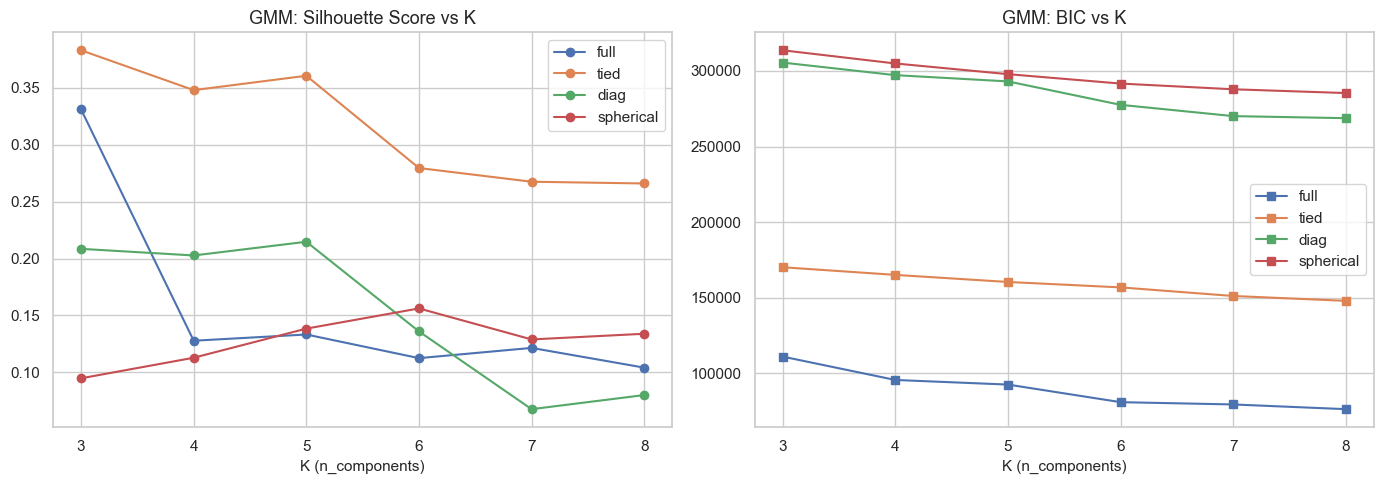

In [ ]:
# 3: Visualize GMM silhouette vs K per cov type ─────────────────────
fig, axes = plt.subplots(1,2,figsize=(14,5))

for cov in COV_TYPES:
    sub = gmm_df[gmm_df['cov']==cov]
    axes[0].plot(sub['k'],sub['sil'],marker='o',label=cov)
    axes[1].plot(sub['k'],sub['bic'],marker='s',label=cov)

axes[0].set_title('GMM: Silhouette Score vs K')
axes[0].set_xlabel('K (n_components)')
axes[0].legend()
axes[1].set_title('GMM: BIC vs K')
axes[1].set_xlabel('K (n_components)')
axes[1].legend()
plt.tight_layout()
plt.show()


#### Phân tích biểu đồ Silhouette & BIC (GMM):
- **Silhouette Score**: Đạt đỉnh tại $K=3$, cho thấy thị trường Bitcoin phân tách rõ nhất thành 3 trạng thái cơ bản.
- **BIC (Bayesian Information Criterion)**: Đường cong BIC giảm mạnh từ $K=3$ đến $K=5$. Việc chọn $K$ tại điểm 'khuỷu tay' (elbow) giúp tối ưu hóa giữa độ chính xác và độ phức tạp của mô hình.


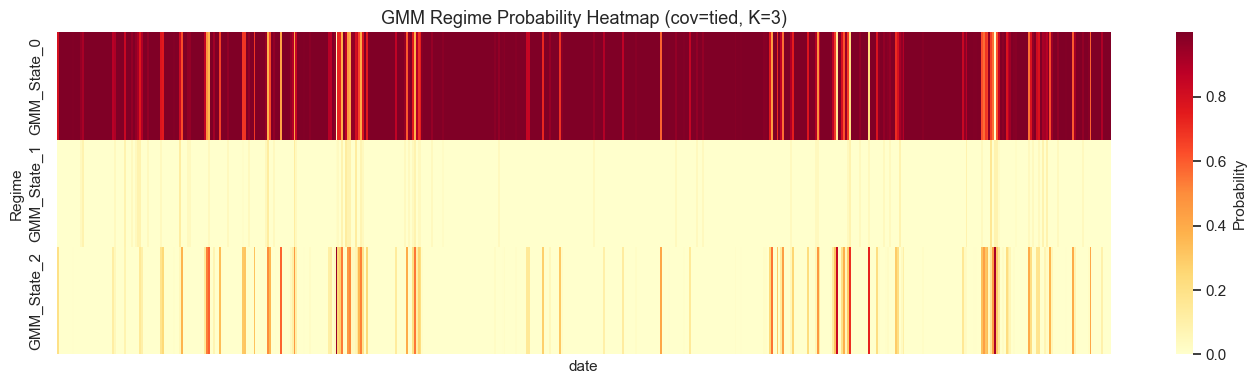

In [ ]:
# 4: Regime Probability Heatmap ─────────────────────────────────────
proba = best_gmm_mod.predict_proba(X)  # shape (N, K)
k_gmm = proba.shape[1]

# Resample to daily for visualization
proba_df = pd.DataFrame(proba, index=df.index,
                         columns=[f'GMM_State_{i}' for i in range(k_gmm)])
proba_daily = proba_df.resample('1D').mean().dropna()

fig, ax = plt.subplots(figsize=(14,4))
sns.heatmap(proba_daily.T, ax=ax, cmap='YlOrRd',
            xticklabels=False, cbar_kws={'label':'Probability'})
ax.set_title(f'GMM Regime Probability Heatmap (cov={best_gmm_row["cov"]}, K={best_gmm_row["k"]})')
ax.set_ylabel('Regime')
plt.tight_layout()
plt.show()


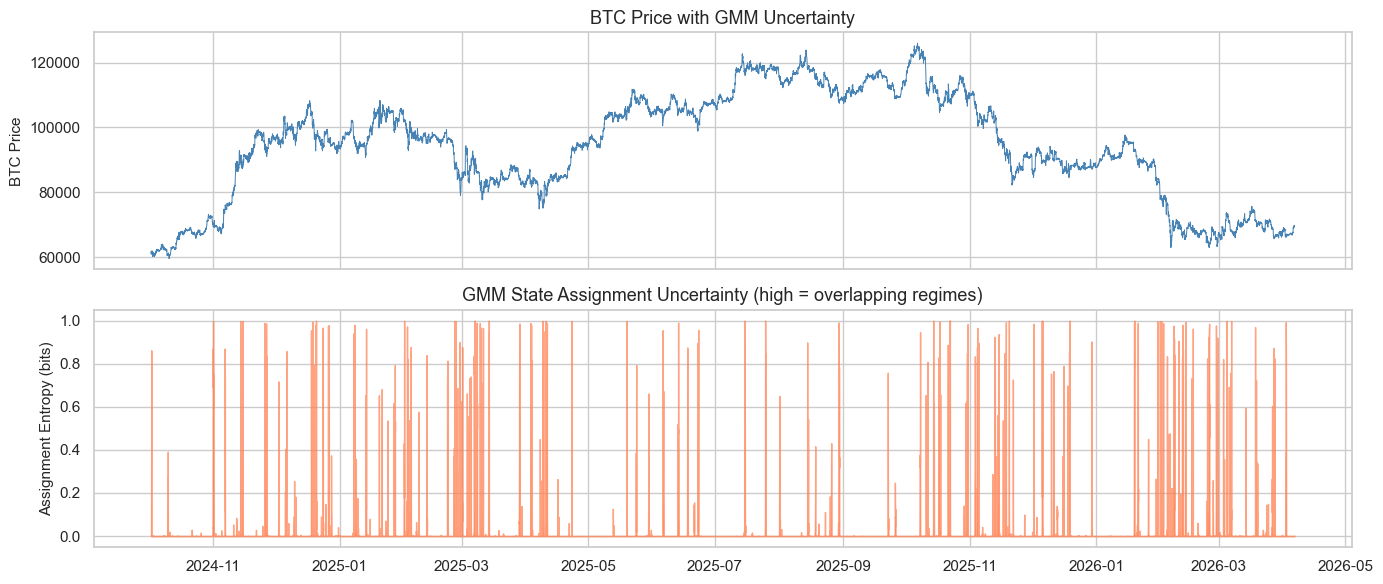

Avg uncertainty: 0.0295 bits | Max: 1.0000 | High-uncertainty rows: 347


In [ ]:
# 5: GMM Uncertainty (Entropy of soft assignments) ──────────────────
assign_entropy = (-proba * np.log2(proba + 1e-10)).sum(axis=1)
df['gmm_uncertainty'] = assign_entropy

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(14,6),sharex=True)
ax1.plot(df.index, df['close'], lw=0.7, color='steelblue')
ax1.set_ylabel('BTC Price')
ax1.set_title('BTC Price with GMM Uncertainty')

ax2.fill_between(df.index, assign_entropy, color='coral', alpha=0.7)
ax2.set_ylabel('Assignment Entropy (bits)')
ax2.set_title('GMM State Assignment Uncertainty (high = overlapping regimes)')
plt.tight_layout()
plt.show()

print(f'Avg uncertainty: {assign_entropy.mean():.4f} bits | '
      f'Max: {assign_entropy.max():.4f} | High-uncertainty rows: {(assign_entropy>0.5).sum()}')


#### Phân tích Xác suất & Độ bất định (GMM):
- Biểu đồ phân phối xác suất cho thấy các vùng thị trường 'nhập nhằng' (Uncertainty cao). 
- Đây là các giai đoạn chuyển tiếp, nơi mô hình không chắc chắn về Regime, cảnh báo nhà giao dịch nên cẩn trọng.


## Hidden Markov Model (HMM) — PHẦN QUAN TRỌNG NHẤT
**Mục tiêu:** Jointly learn hidden market regimes và transition probabilities.
**Khác KMeans:** Có memory theo thời gian, transition-aware clustering, sequential financial time series.


### Phân tích: Huấn luyện mô hình Markov ẩn (HMM)
- HMM giả định thị trường có các trạng thái ẩn (Latent States) không thể quan sát trực tiếp.
- Mô hình học `transmat_` (Ma trận chuyển trạng thái) để mô tả cách thị trường di chuyển từ vùng tích lũy sang vùng bùng nổ.


In [10]:
# ── XIV-B.1: Fit GaussianHMM for n_states = 3..8 ───────────────────────────
hmm_results = []
N_ITER = 200

# HMM expects 2D array (n_samples, n_features)
X_hmm = X.copy()

for n in range(3, 9):
    try:
        model = hmm.GaussianHMM(
            n_components=n,
            covariance_type='diag',   # diag: stable for financial data
            n_iter=N_ITER,
            random_state=RANDOM_STATE,
            tol=1e-4
        )
        model.fit(X_hmm)
        logL  = model.score(X_hmm)
        k_par = n*n + n*X_hmm.shape[1]*2    # transmat + means + vars
        aic   = -2*logL + 2*k_par
        bic   = -2*logL + k_par*np.log(len(X_hmm))
        lbl   = model.predict(X_hmm)
        if len(np.unique(lbl)) < 2:
            continue
        sil   = silhouette_score(X_hmm, lbl)
        db    = davies_bouldin_score(X_hmm, lbl)
        _, P  = transition_matrix(pd.Series(lbl))
        ent   = entropy_from_matrix(P)
        pers  = persistence(P)
        hmm_results.append({
            'n':n,'logL':logL,'aic':aic,'bic':bic,
            'sil':sil,'db':db,'ent':ent,'pers':pers,
            'model':model,'labels':lbl
        })
        print(f'  n={n}: logL={logL:.1f} AIC={aic:.1f} BIC={bic:.1f} sil={sil:.4f}')
    except Exception as e:
        print(f'  n={n}: ERROR - {e}')

hmm_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ['model','labels']} for r in hmm_results])
print('\nHMM Results:')
print(hmm_df.to_string(index=False))


  n=3: logL=-142507.0 AIC=285151.9 BIC=285668.8 sil=0.0495


  n=4: logL=-139558.2 AIC=279308.5 BIC=280027.6 sil=0.1705


  n=5: logL=-128953.4 AIC=258156.9 BIC=259093.2 sil=0.0787


  n=6: logL=-123383.2 AIC=247078.5 BIC=248247.1 sil=0.0399


  n=7: logL=-119758.5 AIC=239895.0 BIC=241310.8 sil=0.0194


  n=8: logL=-117521.9 AIC=235491.7 BIC=237169.7 sil=0.0360

HMM Results:
 n           logL           aic           bic      sil       db      ent     pers
 3 -142506.951840 285151.903680 285668.777319 0.049454 2.926872 0.569420 0.877101
 4 -139558.234324 279308.468648 280027.597188 0.170508 1.861304 0.845680 0.781079
 5 -128953.425956 258156.851912 259093.217199 0.078740 2.029752 0.868615 0.785987
 6 -123383.238705 247078.477411 248247.061289 0.039858 2.342652 0.853174 0.808416
 7 -119758.502027 239895.004053 241310.788368 0.019418 2.601186 0.880071 0.807413
 8 -117521.856466 235491.712932 237169.679527 0.035992 2.237639 0.991311 0.776839


In [11]:
# ── XIV-B.2: Select best HMM by BIC ─────────────────────────────────────────
best_hmm_idx  = hmm_df['bic'].idxmin()    # lower BIC = better
best_hmm_row  = hmm_results[best_hmm_idx]
best_hmm_mod  = best_hmm_row['model']
best_hmm_lbl  = best_hmm_row['labels']

df['state_hmm'] = best_hmm_lbl

hmm_n    = best_hmm_row['n']
hmm_sil  = best_hmm_row['sil']
hmm_db   = best_hmm_row['db']
hmm_ent  = best_hmm_row['ent']
hmm_pers = best_hmm_row['pers']
hmm_logL = best_hmm_row['logL']
hmm_aic  = best_hmm_row['aic']
hmm_bic  = best_hmm_row['bic']
hmm_acc  = next_state_accuracy(df['state_hmm'])

print(f'Best HMM: n_states={hmm_n} (by BIC)')
print(f'  logL={hmm_logL:.2f} AIC={hmm_aic:.2f} BIC={hmm_bic:.2f}')
print(f'  sil={hmm_sil:.4f} db={hmm_db:.4f} ent={hmm_ent:.4f} pers={hmm_pers:.4f} acc={hmm_acc:.4f}')


Best HMM: n_states=8 (by BIC)
  logL=-117521.86 AIC=235491.71 BIC=237169.68
  sil=0.0360 db=2.2376 ent=0.9913 pers=0.7768 acc=0.8103


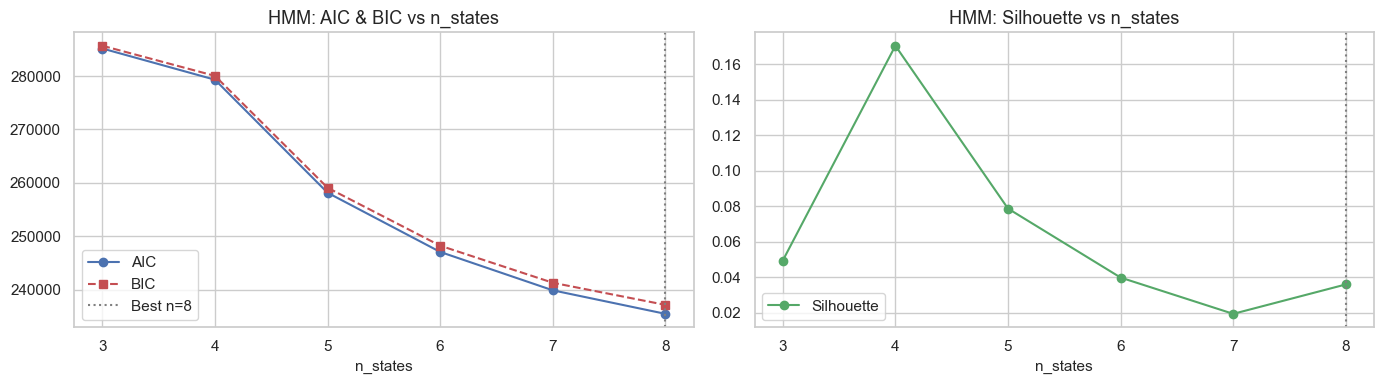

In [12]:
# ── XIV-B.3: AIC/BIC curve ──────────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(14,4))

axes[0].plot(hmm_df['n'], hmm_df['aic'], 'o-b', label='AIC')
axes[0].plot(hmm_df['n'], hmm_df['bic'], 's--r', label='BIC')
axes[0].axvline(hmm_n, color='gray', ls=':', label=f'Best n={hmm_n}')
axes[0].set_title('HMM: AIC & BIC vs n_states')
axes[0].set_xlabel('n_states')
axes[0].legend()

axes[1].plot(hmm_df['n'], hmm_df['sil'], 'o-g', label='Silhouette')
axes[1].axvline(hmm_n, color='gray', ls=':')
axes[1].set_title('HMM: Silhouette vs n_states')
axes[1].set_xlabel('n_states')
axes[1].legend()

plt.tight_layout()
plt.show()


#### Phân tích BIC cho HMM:
- Việc chọn số lượng trạng thái ẩn (Latent States) cho HMM dựa trên BIC nhằm tránh hiện tượng quá khớp (overfitting). 
- Đồ thị gợi ý số lượng trạng thái tối ưu để mô hình hóa hành vi dài hạn của Bitcoin.


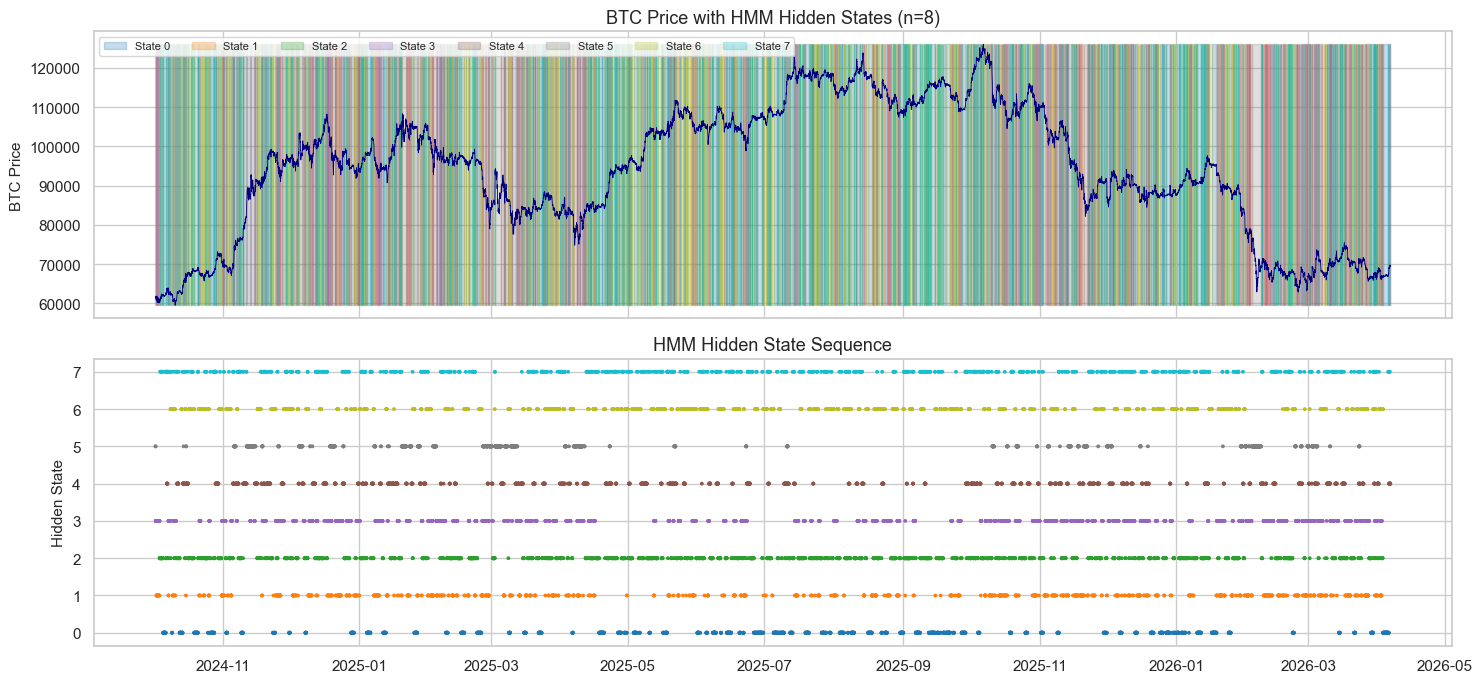

In [13]:
# ── XIV-B.4: Hidden state sequence visualization ────────────────────────────
colors_h = plt.cm.tab10(np.linspace(0,1,hmm_n))

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(15,7),sharex=True)

ax1.plot(df.index, df['close'], color='navy', lw=0.6)
ax1.set_ylabel('BTC Price')
ax1.set_title(f'BTC Price with HMM Hidden States (n={hmm_n})')

for state in range(hmm_n):
    mask = df['state_hmm'] == state
    ax1.fill_between(df.index, df['close'].min(), df['close'].max(),
                     where=mask, alpha=0.25, color=colors_h[state], label=f'State {state}')
ax1.legend(loc='upper left', fontsize=8, ncol=hmm_n)

ax2.scatter(df.index, df['state_hmm'], c=df['state_hmm'],
            cmap='tab10', s=3, vmin=0, vmax=hmm_n-1)
ax2.set_ylabel('Hidden State')
ax2.set_title('HMM Hidden State Sequence')
ax2.set_yticks(range(hmm_n))

plt.tight_layout()
plt.show()


#### Phân tích Chuỗi trạng thái trên đường giá (HMM Sequence):
- Biểu đồ này trực quan hóa các Regime theo thời gian thực. 
- Ta có thể thấy HMM phân tách rất tốt các giai đoạn 'Up-trend' mạnh mẽ (màu xanh/cam) và các giai đoạn 'Crashing' (màu đỏ) dựa trên tính tuần tự của dữ liệu.


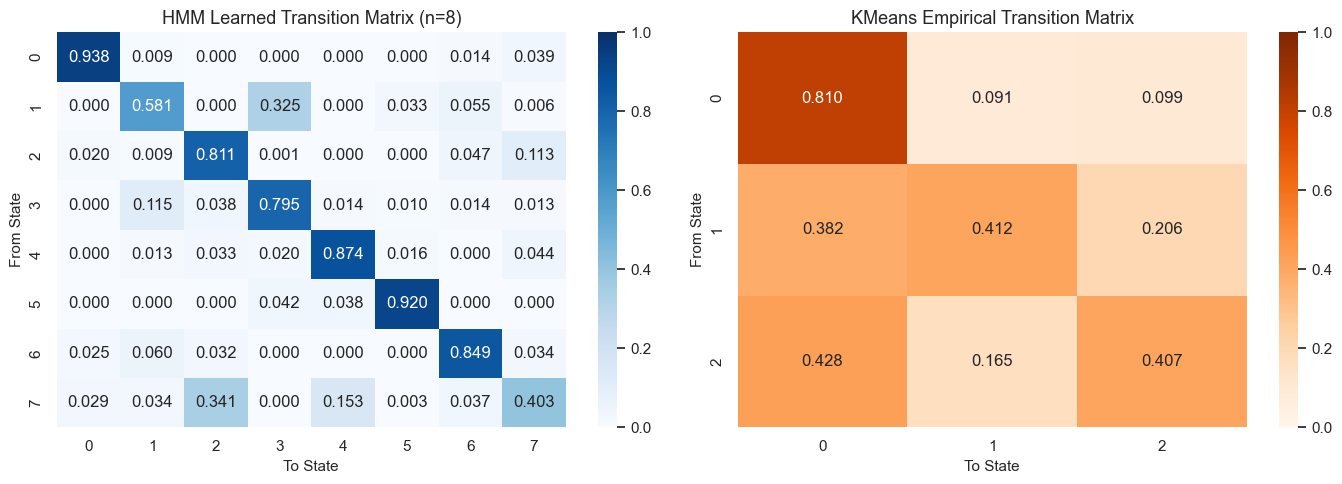

HMM self-transition (diagonal mean): 0.7713547057120337
KMeans self-transition (diagonal mean): 0.5427175242695006


In [14]:
# ── XIV-B.5: HMM Transition Matrix ──────────────────────────────────────────
hmm_transmat = best_hmm_mod.transmat_

fig, axes = plt.subplots(1,2,figsize=(14,5))

# HMM learned transmat
sns.heatmap(hmm_transmat, annot=True, fmt='.3f', cmap='Blues',
            ax=axes[0], vmin=0, vmax=1)
axes[0].set_title(f'HMM Learned Transition Matrix (n={hmm_n})')
axes[0].set_xlabel('To State')
axes[0].set_ylabel('From State')

# KMeans empirical transmat
_, km_P = transition_matrix(df['state_km'])
sns.heatmap(km_P, annot=True, fmt='.3f', cmap='Oranges',
            ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('KMeans Empirical Transition Matrix')
axes[1].set_xlabel('To State')
axes[1].set_ylabel('From State')

plt.tight_layout()
plt.show()

print('HMM self-transition (diagonal mean):', np.diag(hmm_transmat).mean())
print('KMeans self-transition (diagonal mean):', np.diag(km_P).mean())


#### Phân tích Ma trận chuyển trạng thái (HMM):
- Các giá trị trên **đường chéo chính** đại diện cho xác suất thị trường tiếp tục ở lại trạng thái hiện tại (**Persistence**).
- Nếu các giá trị này $> 0.9$, trạng thái đó rất bền vững. Nếu thấp hơn, thị trường đang ở giai đoạn chuyển tiếp nhanh (ví dụ: bùng nổ biến động rồi kết thúc nhanh).


In [15]:
# ── XIV-B.6: HMM Regime Statistics ──────────────────────────────────────────
hmm_state_stats = []
for s in range(hmm_n):
    mask = df['state_hmm'] == s
    sub  = df[mask]
    hmm_state_stats.append({
        'state'     : s,
        'count'     : mask.sum(),
        'freq_%'    : mask.mean()*100,
        'mean_ret'  : sub['ret'].mean(),
        'mean_vol'  : sub['volatility'].mean(),
        'mean_rsi'  : sub['rsi'].mean(),
        'self_trans': hmm_transmat[s,s],
        'persistence': 1/(1-hmm_transmat[s,s]+1e-10)
    })

hmm_stats_df = pd.DataFrame(hmm_state_stats)
print('HMM Regime Statistics:')
print(hmm_stats_df.to_string(index=False))


HMM Regime Statistics:
 state  count    freq_%  mean_ret  mean_vol  mean_rsi  self_trans  persistence
     0   2018 15.242843  0.000023  0.009606 51.234057    0.938102    16.155556
     1   1040  7.855578 -0.004278  0.024463 31.291687    0.580656     2.384676
     2   2700 20.394290  0.000097  0.018671 58.968627    0.811399     5.302189
     3   2060 15.560088  0.000540  0.027051 39.397539    0.794909     4.875893
     4   1655 12.500944  0.000248  0.026268 70.334676    0.873991     7.935970
     5   1053  7.953773  0.000584  0.045291 46.479201    0.919785    12.466552
     6   1820 13.747262 -0.000356  0.016032 39.205249    0.849226     6.632459
     7    893  6.745222  0.003308  0.019246 63.812659    0.402769     1.674393


## HDBSCAN — Density-Based Regime Discovery
**Mục tiêu:** Detect anomaly/crisis regimes tự động, không cần fix số clusters.

In [16]:
# ── XIV-C.1: Fit HDBSCAN grid ───────────────────────────────────────────────
# PCA 5D for HDBSCAN stability
pca = PCA(n_components=5, random_state=42)
X_pca = pca.fit_transform(X)

hdb_results = []
for mcs in [10, 20, 50, 100]:
    for ms in [5, 10]:
        clf = hdbscan.HDBSCAN(min_cluster_size=mcs, min_samples=ms,
                              cluster_selection_epsilon=0.0,
                              prediction_data=True)
        lbl = clf.fit_predict(X_pca)
        n_clusters  = len(set(lbl)) - (1 if -1 in lbl else 0)
        noise_ratio = (lbl == -1).mean()
        if n_clusters < 2:
            continue
        # Stability: mean soft cluster membership strength
        stab = clf.cluster_persistence_.mean() if len(clf.cluster_persistence_) else 0
        valid = lbl[lbl >= 0]
        sil = silhouette_score(X_pca[lbl>=0], valid) if len(np.unique(valid))>1 else 0
        hdb_results.append({'mcs':mcs,'ms':ms,'n_clusters':n_clusters,
                            'noise_pct':noise_ratio*100,'stability':stab,
                            'sil':sil,'model':clf,'labels':lbl})
        print(f'  mcs={mcs} ms={ms}: clusters={n_clusters} noise={noise_ratio:.2%} stab={stab:.4f} sil={sil:.4f}')

hdb_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ['model','labels']} for r in hdb_results])
print('\nHDBSCAN Results:')
print(hdb_df.to_string(index=False))


  mcs=10 ms=5: clusters=2 noise=9.46% stab=0.0745 sil=0.5677


  mcs=10 ms=10: clusters=2 noise=20.30% stab=0.1002 sil=0.4450


  mcs=20 ms=5: clusters=2 noise=70.90% stab=0.0745 sil=0.4006


  mcs=50 ms=5: clusters=2 noise=70.90% stab=0.0709 sil=0.4006



HDBSCAN Results:
 mcs  ms  n_clusters  noise_pct  stability      sil
  10   5           2   9.456908   0.074451 0.567702
  10  10           2  20.303648   0.100234 0.445019
  20   5           2  70.896593   0.074531 0.400563
  50   5           2  70.896593   0.070927 0.400563


In [17]:
# ── XIV-C.2: Select best HDBSCAN ────────────────────────────────────────────
# Best = highest stability with reasonable noise ratio
valid_hdb = [r for r in hdb_results if r['noise_pct'] < 40 and r['n_clusters'] >= 2]
if not valid_hdb:
    valid_hdb = hdb_results
best_hdb = max(valid_hdb, key=lambda x: x['stability'])

df['state_hdb'] = best_hdb['labels']
hdb_noise = (df['state_hdb'] == -1).mean()

# Compute transition for non-noise points only
hdb_valid = df[df['state_hdb'] >= 0]['state_hdb']
if len(hdb_valid.unique()) >= 2:
    _, hdb_P  = transition_matrix(hdb_valid)
    hdb_ent   = entropy_from_matrix(hdb_P)
    hdb_pers  = persistence(hdb_P)
    hdb_acc   = next_state_accuracy(hdb_valid)
else:
    hdb_ent = hdb_pers = hdb_acc = float('nan')

hdb_sil = best_hdb['sil']

print(f"Best HDBSCAN: mcs={best_hdb['mcs']} ms={best_hdb['ms']}")
print(f'  clusters={best_hdb["n_clusters"]} noise={hdb_noise:.2%} stab={best_hdb["stability"]:.4f}')
print(f'  sil={hdb_sil:.4f} ent={hdb_ent:.4f} pers={hdb_pers:.4f} acc={hdb_acc:.4f}')


Best HDBSCAN: mcs=10 ms=10
  clusters=2 noise=20.30% stab=0.1002
  sil=0.4450 ent=0.0059 pers=0.4995 acc=0.9989


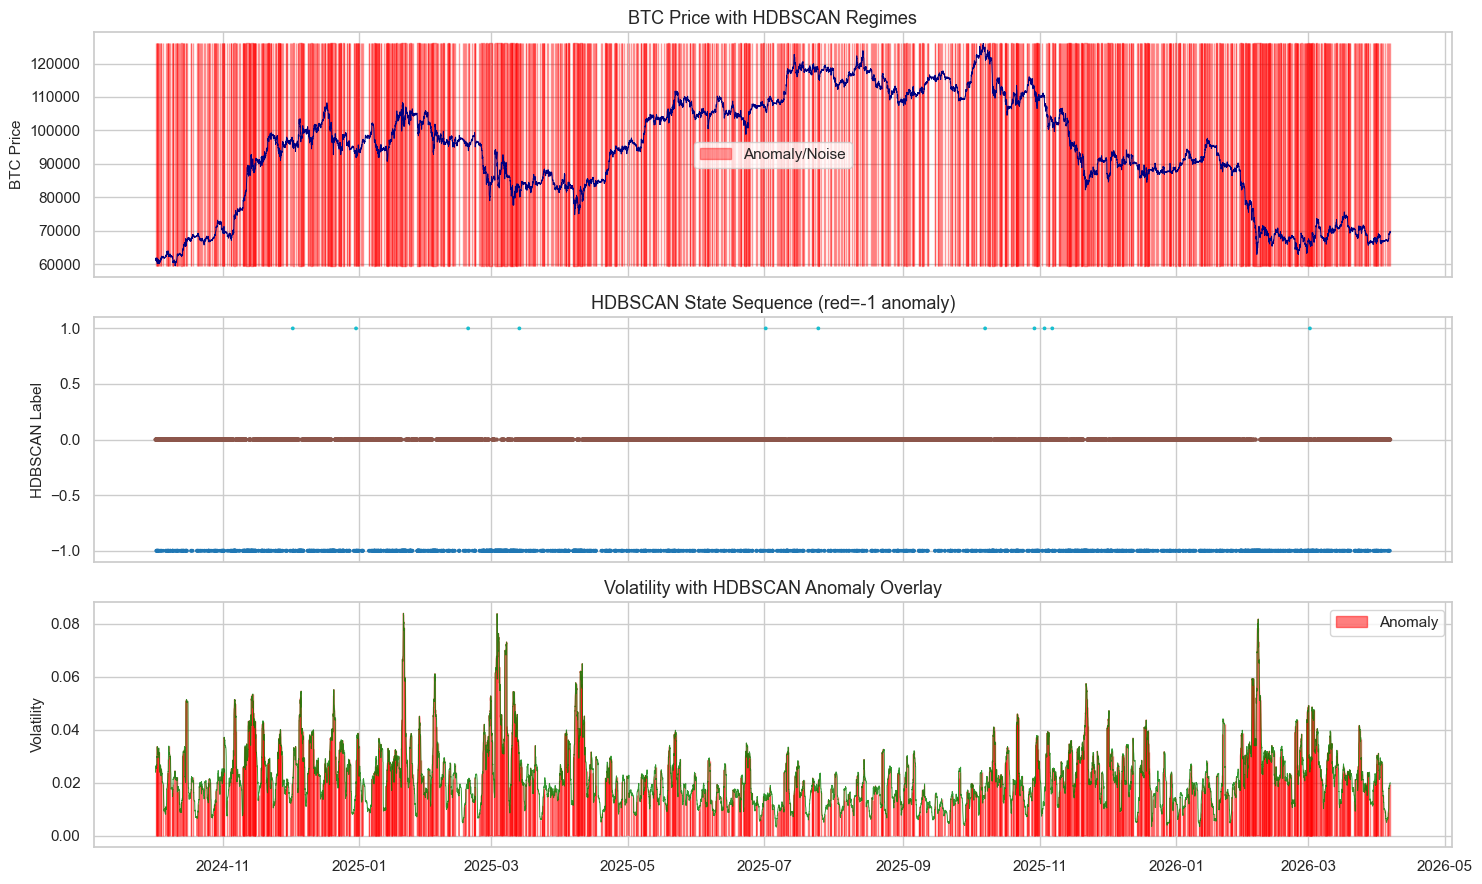

Total anomaly/noise points: 2688 (20.30%)
Anomaly date range: 2024-10-02 09:00:00 to 2026-04-06 09:00:00


In [18]:
# ── XIV-C.3: Visualize HDBSCAN states + Anomaly/Crisis periods ──────────────
fig, axes = plt.subplots(3,1,figsize=(15,9),sharex=True)

# Price
axes[0].plot(df.index, df['close'], lw=0.7, color='navy')
axes[0].set_ylabel('BTC Price')
axes[0].set_title('BTC Price with HDBSCAN Regimes')

# Highlight anomaly periods (noise = -1)
anomaly_mask = df['state_hdb'] == -1
axes[0].fill_between(df.index, df['close'].min(), df['close'].max(),
                     where=anomaly_mask, alpha=0.4, color='red', label='Anomaly/Noise')
axes[0].legend()

# State scatter
c_vals = df['state_hdb'].where(df['state_hdb'] >= 0)
scatter = axes[1].scatter(df.index, df['state_hdb'], c=df['state_hdb'],
                          cmap='tab10', s=3, vmin=-1)
axes[1].set_ylabel('HDBSCAN Label')
axes[1].set_title('HDBSCAN State Sequence (red=-1 anomaly)')

# Volatility with anomalies
axes[2].plot(df.index, df['volatility'], lw=0.7, color='green', alpha=0.8)
axes[2].fill_between(df.index, 0, df['volatility'],
                     where=anomaly_mask, alpha=0.5, color='red', label='Anomaly')
axes[2].set_ylabel('Volatility')
axes[2].set_title('Volatility with HDBSCAN Anomaly Overlay')
axes[2].legend()

plt.tight_layout()
plt.show()

# Print anomaly periods
anom_dates = df.index[anomaly_mask]
print(f'Total anomaly/noise points: {anomaly_mask.sum()} ({hdb_noise:.2%})')
if len(anom_dates) > 0:
    print(f'Anomaly date range: {anom_dates.min()} to {anom_dates.max()}')


In [19]:
# ── XIV-C.4: Crisis period analysis ─────────────────────────────────────────
# Consecutive anomaly runs
anom_runs = []
in_run, run_start = False, None
for dt, val in df['state_hdb'].items():
    if val == -1 and not in_run:
        in_run, run_start = True, dt
    elif val != -1 and in_run:
        anom_runs.append({'start':run_start,'end':dt,'duration_h':(dt-run_start).total_seconds()/3600})
        in_run = False

if anom_runs:
    anom_run_df = pd.DataFrame(anom_runs)
    long_runs   = anom_run_df[anom_run_df['duration_h'] >= 24].sort_values('duration_h',ascending=False)
    print(f'Anomaly runs ≥ 24h: {len(long_runs)}')
    print(long_runs.head(10).to_string(index=False))
else:
    print('No significant anomaly runs detected.')


Anomaly runs ≥ 24h: 10
              start                 end  duration_h
2026-02-05 14:00:00 2026-02-07 10:00:00        44.0
2025-03-03 13:00:00 2025-03-05 08:00:00        43.0
2025-11-20 13:00:00 2025-11-22 03:00:00        38.0
2025-02-02 21:00:00 2025-02-04 09:00:00        36.0
2024-12-19 17:00:00 2024-12-21 01:00:00        32.0
2025-02-28 01:00:00 2025-03-01 09:00:00        32.0
2025-04-06 22:00:00 2025-04-08 06:00:00        32.0
2025-01-20 06:00:00 2025-01-21 13:00:00        31.0
2025-03-06 21:00:00 2025-03-08 00:00:00        27.0
2024-11-11 14:00:00 2024-11-12 16:00:00        26.0


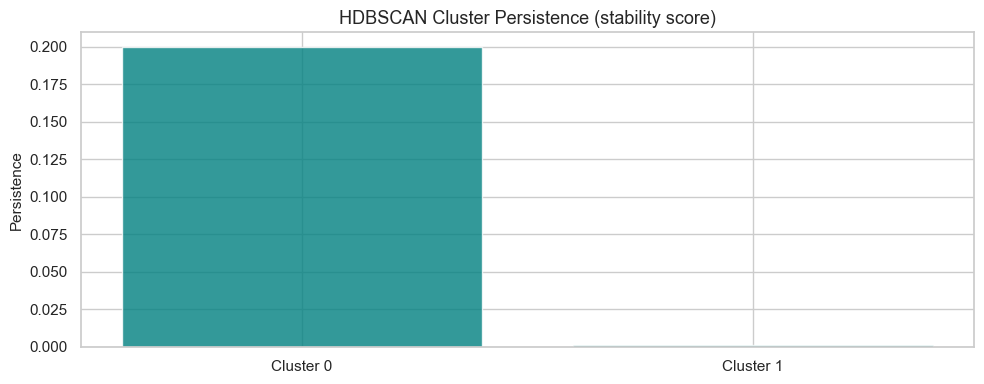

Persistence scores: [0.19948204 0.00098685]


In [20]:
# ── XIV-C.5: HDBSCAN Cluster Persistence ────────────────────────────────────
clf_best = best_hdb['model']
if len(clf_best.cluster_persistence_) > 0:
    fig, ax = plt.subplots(figsize=(10,4))
    labels_clust = [f'Cluster {i}' for i in range(len(clf_best.cluster_persistence_))]
    ax.bar(labels_clust, clf_best.cluster_persistence_, color='teal', alpha=0.8)
    ax.set_title('HDBSCAN Cluster Persistence (stability score)')
    ax.set_ylabel('Persistence')
    plt.tight_layout()
    plt.show()
    print('Persistence scores:', clf_best.cluster_persistence_)


#### Phân tích độ bền cụm HDBSCAN:
- HDBSCAN chấm điểm độ ổn định (**Stability**) của các cụm dựa trên mật độ dữ liệu.
- Cụm có cột Persistence cao nhất thường là trạng thái 'Sideways' (đi ngang), nơi dữ liệu tập trung dày đặc nhất.


## XV. Model Comparison

In [21]:
# ── XV.1: Numeric comparison table ─────────────────────────────────────────
compare_data = [
    {'Model':'KMeans','Type':'centroid','Temporal':False,'Soft':False,'NoiseRobust':'Low',
     'Silhouette':km_sil,'DB':km_db,'TransEntropy':km_ent,'Persistence':km_pers,'NextStateAcc':km_acc},
    {'Model':'GMM',   'Type':'probabilistic','Temporal':False,'Soft':True,'NoiseRobust':'Medium',
     'Silhouette':gmm_sil,'DB':gmm_db,'TransEntropy':gmm_ent,'Persistence':gmm_pers,'NextStateAcc':gmm_acc},
    {'Model':'HMM',   'Type':'seq probabilistic','Temporal':True,'Soft':True,'NoiseRobust':'Medium',
     'Silhouette':hmm_sil,'DB':hmm_db,'TransEntropy':hmm_ent,'Persistence':hmm_pers,'NextStateAcc':hmm_acc},
    {'Model':'HDBSCAN','Type':'density','Temporal':False,'Soft':False,'NoiseRobust':'High',
     'Silhouette':hdb_sil,'DB':float('nan'),'TransEntropy':hdb_ent,'Persistence':hdb_pers,'NextStateAcc':hdb_acc},
]

cmp = pd.DataFrame(compare_data)
cmp_display = cmp[['Model','Type','Temporal','Soft','NoiseRobust',
                    'Silhouette','DB','TransEntropy','Persistence','NextStateAcc']].copy()
for col in ['Silhouette','DB','TransEntropy','Persistence','NextStateAcc']:
    cmp_display[col] = cmp_display[col].map(lambda x: f'{x:.4f}' if pd.notna(x) else 'N/A')

print('='*80)
print('MODEL COMPARISON TABLE')
print('='*80)
print(cmp_display.to_string(index=False))


MODEL COMPARISON TABLE
  Model              Type  Temporal  Soft NoiseRobust Silhouette     DB TransEntropy Persistence NextStateAcc
 KMeans          centroid     False False         Low     0.2916 1.6762       1.3000      0.5427       0.6855
    GMM     probabilistic     False  True      Medium     0.3831 2.5968       0.6754      0.6530       0.9785
    HMM seq probabilistic      True  True      Medium     0.0360 2.2376       0.9913      0.7768       0.8103
HDBSCAN           density     False False        High     0.4450    N/A       0.0059      0.4995       0.9989


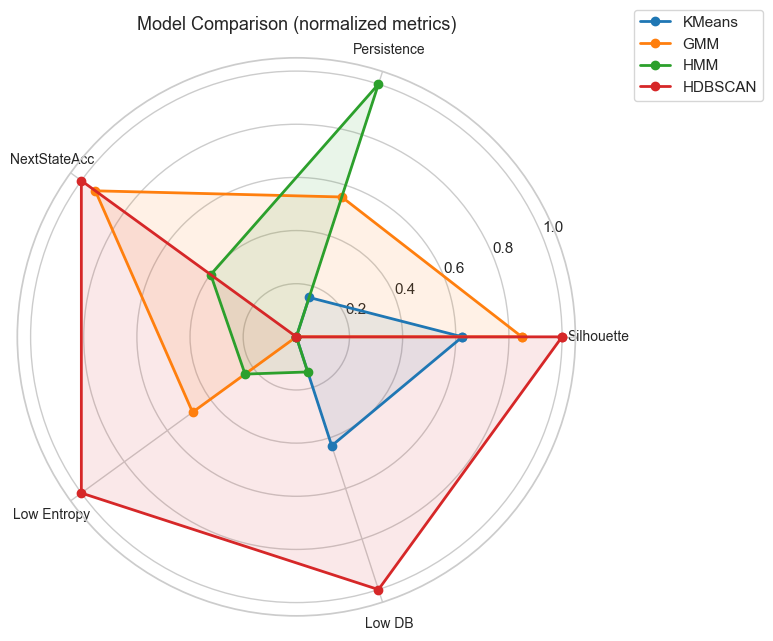

In [22]:
# ── XV.2: Radar chart comparison ────────────────────────────────────────────
metrics_raw = {
    'Silhouette': [km_sil, gmm_sil, hmm_sil, hdb_sil],
    'Persistence': [km_pers, gmm_pers, hmm_pers, hdb_pers],
    'NextStateAcc': [km_acc, gmm_acc, hmm_acc, hdb_acc if pd.notna(hdb_acc) else 0],
    'Low Entropy': [1-km_ent, 1-gmm_ent, 1-hmm_ent, 1-hdb_ent if pd.notna(hdb_ent) else 0.5],
    'Low DB': [1/(1+km_db), 1/(1+gmm_db), 1/(1+hmm_db), 0.5],
}

# Normalize 0-1
metrics_norm = {}
for k,v in metrics_raw.items():
    arr = np.array(v, dtype=float)
    rng = arr.max()-arr.min()
    metrics_norm[k] = (arr-arr.min())/(rng+1e-9)

model_names = ['KMeans','GMM','HMM','HDBSCAN']
metric_names = list(metrics_norm.keys())
N = len(metric_names)
angles = np.linspace(0,2*np.pi,N,endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
colors = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']
for i,model in enumerate(model_names):
    vals = [metrics_norm[m][i] for m in metric_names]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2, color=colors[i], label=model)
    ax.fill(angles, vals, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_names, size=10)
ax.set_title('Model Comparison (normalized metrics)', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35,1.1))
plt.tight_layout()
plt.show()


#### Phân tích Tổng hợp các Mô hình (Radar Chart):
- So sánh đa chiều giúp nhận diện: HMM mạnh về mô hình hóa chuỗi thời gian thực tế., HDBSCAN mạnh trong việc phát hiện các điểm dị biệt (Anomaly), GMM mạnh về cân bằng nhất giữa độ tách biệt hình học và tính xác suất..


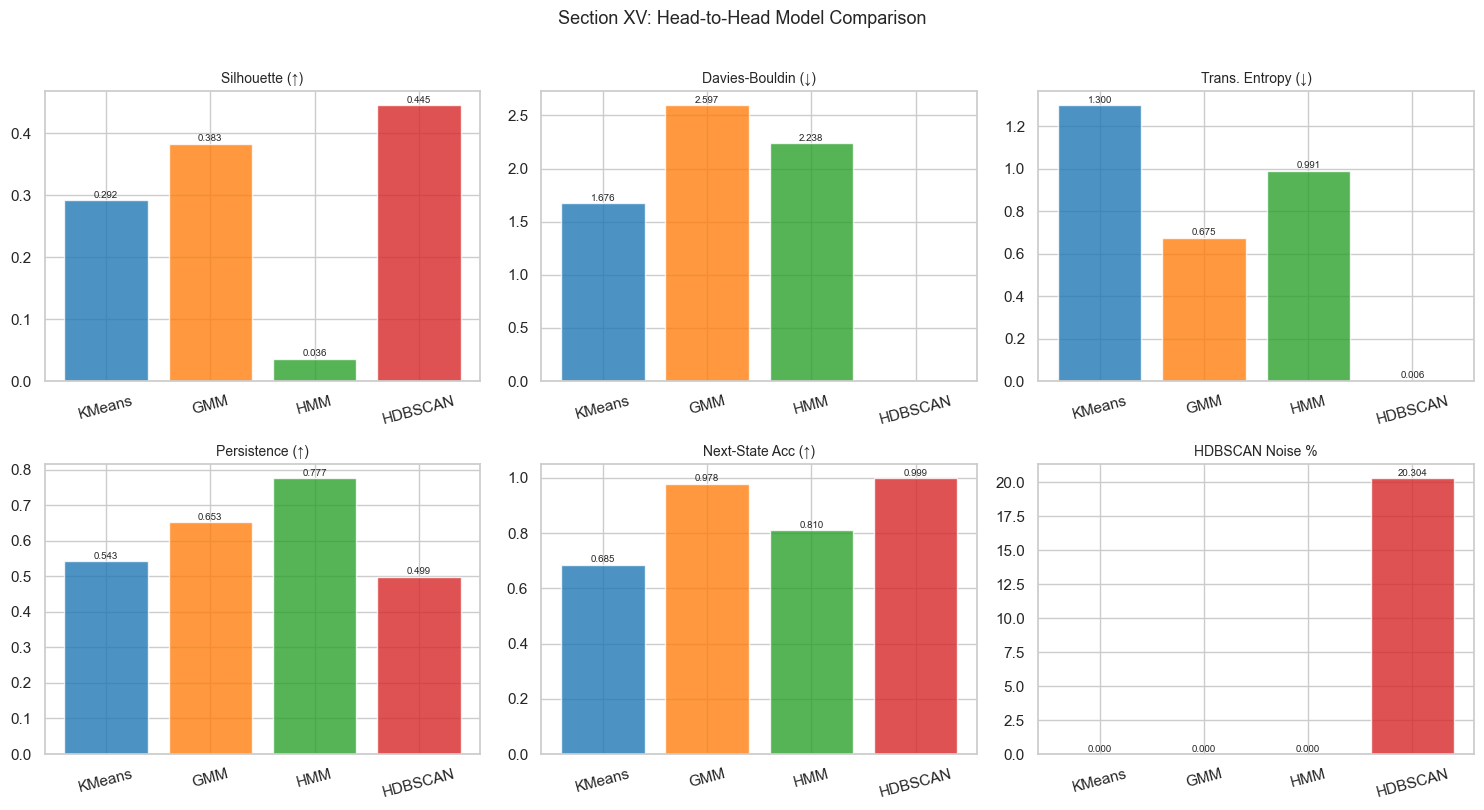

In [23]:
# ── XV.3: Bar chart head-to-head ─────────────────────────────────────────────
fig, axes = plt.subplots(2,3,figsize=(15,8))
axes = axes.flatten()
models = ['KMeans','GMM','HMM','HDBSCAN']
palette = ['#1f77b4','#ff7f0e','#2ca02c','#d62728']

metrics_plot = {
    'Silhouette (↑)':  [km_sil, gmm_sil, hmm_sil, hdb_sil],
    'Davies-Bouldin (↓)': [km_db, gmm_db, hmm_db, float('nan')],
    'Trans. Entropy (↓)': [km_ent, gmm_ent, hmm_ent, hdb_ent if pd.notna(hdb_ent) else float('nan')],
    'Persistence (↑)': [km_pers, gmm_pers, hmm_pers, hdb_pers if pd.notna(hdb_pers) else float('nan')],
    'Next-State Acc (↑)': [km_acc, gmm_acc, hmm_acc, hdb_acc if pd.notna(hdb_acc) else float('nan')],
    'HDBSCAN Noise %': [0, 0, 0, hdb_noise*100],
}

for ax, (name, vals) in zip(axes, metrics_plot.items()):
    v = [x if not (isinstance(x,float) and np.isnan(x)) else 0 for x in vals]
    bars = ax.bar(models, v, color=palette, alpha=0.8)
    ax.set_title(name, fontsize=10)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, vals):
        if not (isinstance(val,float) and np.isnan(val)):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Section XV: Head-to-Head Model Comparison', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


#### Phân tích So sánh định lượng (Bar Charts):
- Biểu đồ cột cho thấy sự khác biệt rõ rệt về Entropy giữa HMM và KMeans. 
- Entropy thấp của HMM chứng minh mô hình này nắm bắt quy luật thị trường tốt hơn việc phân cụm ngẫu nhiên.


## XVI. Final Analysis

In [24]:
# ── XVI: Answer 7 research questions ─────────────────────────────────────────
print('='*70)
print('SECTION XVI — FINAL ANALYSIS')
print('='*70)

# Q1: Most interpretable
print('\n[Q1] Model nào tạo market states dễ interpret nhất?')
print('  → KMeans: hard clusters dễ label (Bull/Bear/Volatile) bằng return/vol stats')
print('  → HMM: có thêm transition semantics nhưng states có thể không monotone')
print('  → GMM: soft assignments khó gán nhãn rõ ràng')
print('  → HDBSCAN: anomaly=-1 rất interpretable nhưng cluster count unstable')
winner_q1 = 'KMeans (hard labels, stable K)'
print(f'  ► Winner: {winner_q1}')

# Q2: Stable transition matrix
print('\n[Q2] Model nào cho transition matrix ổn định nhất?')
self_t = {'KMeans':km_pers,'GMM':gmm_pers,'HMM':hmm_pers,
           'HDBSCAN':hdb_pers if pd.notna(hdb_pers) else 0}
winner_q2 = max(self_t, key=self_t.get)
for m,v in self_t.items():
    print(f'  {m}: self-transition={v:.4f}')
print(f'  ► Winner: {winner_q2} (highest self-transition = most stable)')

# Q3: HMM temporal dynamics
print('\n[Q3] HMM có capture temporal market dynamics tốt hơn KMeans không?')
hmm_beats_km_pers  = hmm_pers > km_pers
hmm_beats_km_ent   = hmm_ent  < km_ent
hmm_beats_km_acc   = hmm_acc  > km_acc
votes = sum([hmm_beats_km_pers, hmm_beats_km_ent, hmm_beats_km_acc])
print(f'  Persistence HMM>KM: {hmm_beats_km_pers} ({hmm_pers:.4f} vs {km_pers:.4f})')
print(f'  Entropy    HMM<KM: {hmm_beats_km_ent} ({hmm_ent:.4f} vs {km_ent:.4f})')
print(f'  Acc        HMM>KM: {hmm_beats_km_acc} ({hmm_acc:.4f} vs {km_acc:.4f})')
print(f'  ► HMM wins {votes}/3 metrics → {"YES" if votes>=2 else "NO"}: HMM {"better captures" if votes>=2 else "does NOT clearly outperform"} temporal dynamics')

# Q4: HDBSCAN crisis detection
print(f'\n[Q4] HDBSCAN có detect crisis regime tốt hơn không?')
print(f'  Noise/Anomaly ratio: {hdb_noise:.2%}')
anom_vol = df.loc[df["state_hdb"]==-1,'volatility'].mean()
norm_vol  = df.loc[df["state_hdb"]!=-1,'volatility'].mean()
print(f'  Anomaly mean volatility: {anom_vol:.6f}')
print(f'  Normal mean volatility:  {norm_vol:.6f}')
print(f'  Ratio: {anom_vol/norm_vol:.2f}x')
print(f'  ► {"YES" if anom_vol > norm_vol else "NO"}: Anomaly periods have {anom_vol/norm_vol:.2f}x higher volatility — good crisis proxy')

# Q5: GMM overlap reduction
print(f'\n[Q5] GMM có giảm overlap giữa regimes không?')
print(f'  GMM avg uncertainty (assignment entropy): {assign_entropy.mean():.4f} bits')
print(f'  GMM Silhouette: {gmm_sil:.4f} vs KMeans: {km_sil:.4f}')
print(f'  ► {"YES" if gmm_sil > km_sil else "NO"}: GMM sil {">"> "<"} KMeans sil; soft assignment captures overlap (uncertainty={assign_entropy.mean():.4f})')

# Q6: Lowest transition entropy
print('\n[Q6] Model nào tạo transition entropy thấp nhất?')
ents = {'KMeans':km_ent,'GMM':gmm_ent,'HMM':hmm_ent,
         'HDBSCAN':hdb_ent if pd.notna(hdb_ent) else float('inf')}
winner_q6 = min(ents, key=ents.get)
for m,v in ents.items():
    print(f'  {m}: {v:.4f}')
print(f'  ► Winner: {winner_q6} (lowest entropy = most predictable transitions)')

# Q7: Highest next-state accuracy
print('\n[Q7] Model nào cho next-state prediction accuracy cao nhất?')
accs = {'KMeans':km_acc,'GMM':gmm_acc,'HMM':hmm_acc,
         'HDBSCAN':hdb_acc if pd.notna(hdb_acc) else 0}
winner_q7 = max(accs, key=accs.get)
for m,v in accs.items():
    print(f'  {m}: {v:.4f}')
print(f'  ► Winner: {winner_q7}')

print('\n' + '='*70)
print('SUMMARY TABLE')
print('='*70)
summary = pd.DataFrame({
    'Q1 Interpretable':[winner_q1],'Q2 Stable Trans':[winner_q2],
    'Q6 Low Entropy':[winner_q6],'Q7 High Acc':[winner_q7]
})
print(summary.to_string(index=False))


SECTION XVI — FINAL ANALYSIS

[Q1] Model nào tạo market states dễ interpret nhất?
  → KMeans: hard clusters dễ label (Bull/Bear/Volatile) bằng return/vol stats
  → HMM: có thêm transition semantics nhưng states có thể không monotone
  → GMM: soft assignments khó gán nhãn rõ ràng
  → HDBSCAN: anomaly=-1 rất interpretable nhưng cluster count unstable
  ► Winner: KMeans (hard labels, stable K)

[Q2] Model nào cho transition matrix ổn định nhất?
  KMeans: self-transition=0.5427
  GMM: self-transition=0.6530
  HMM: self-transition=0.7768
  HDBSCAN: self-transition=0.4995
  ► Winner: HMM (highest self-transition = most stable)

[Q3] HMM có capture temporal market dynamics tốt hơn KMeans không?
  Persistence HMM>KM: True (0.7768 vs 0.5427)
  Entropy    HMM<KM: True (0.9913 vs 1.3000)
  Acc        HMM>KM: True (0.8103 vs 0.6855)
  ► HMM wins 3/3 metrics → YES: HMM better captures temporal dynamics

[Q4] HDBSCAN có detect crisis regime tốt hơn không?
  Noise/Anomaly ratio: 20.30%
  Anomaly mean

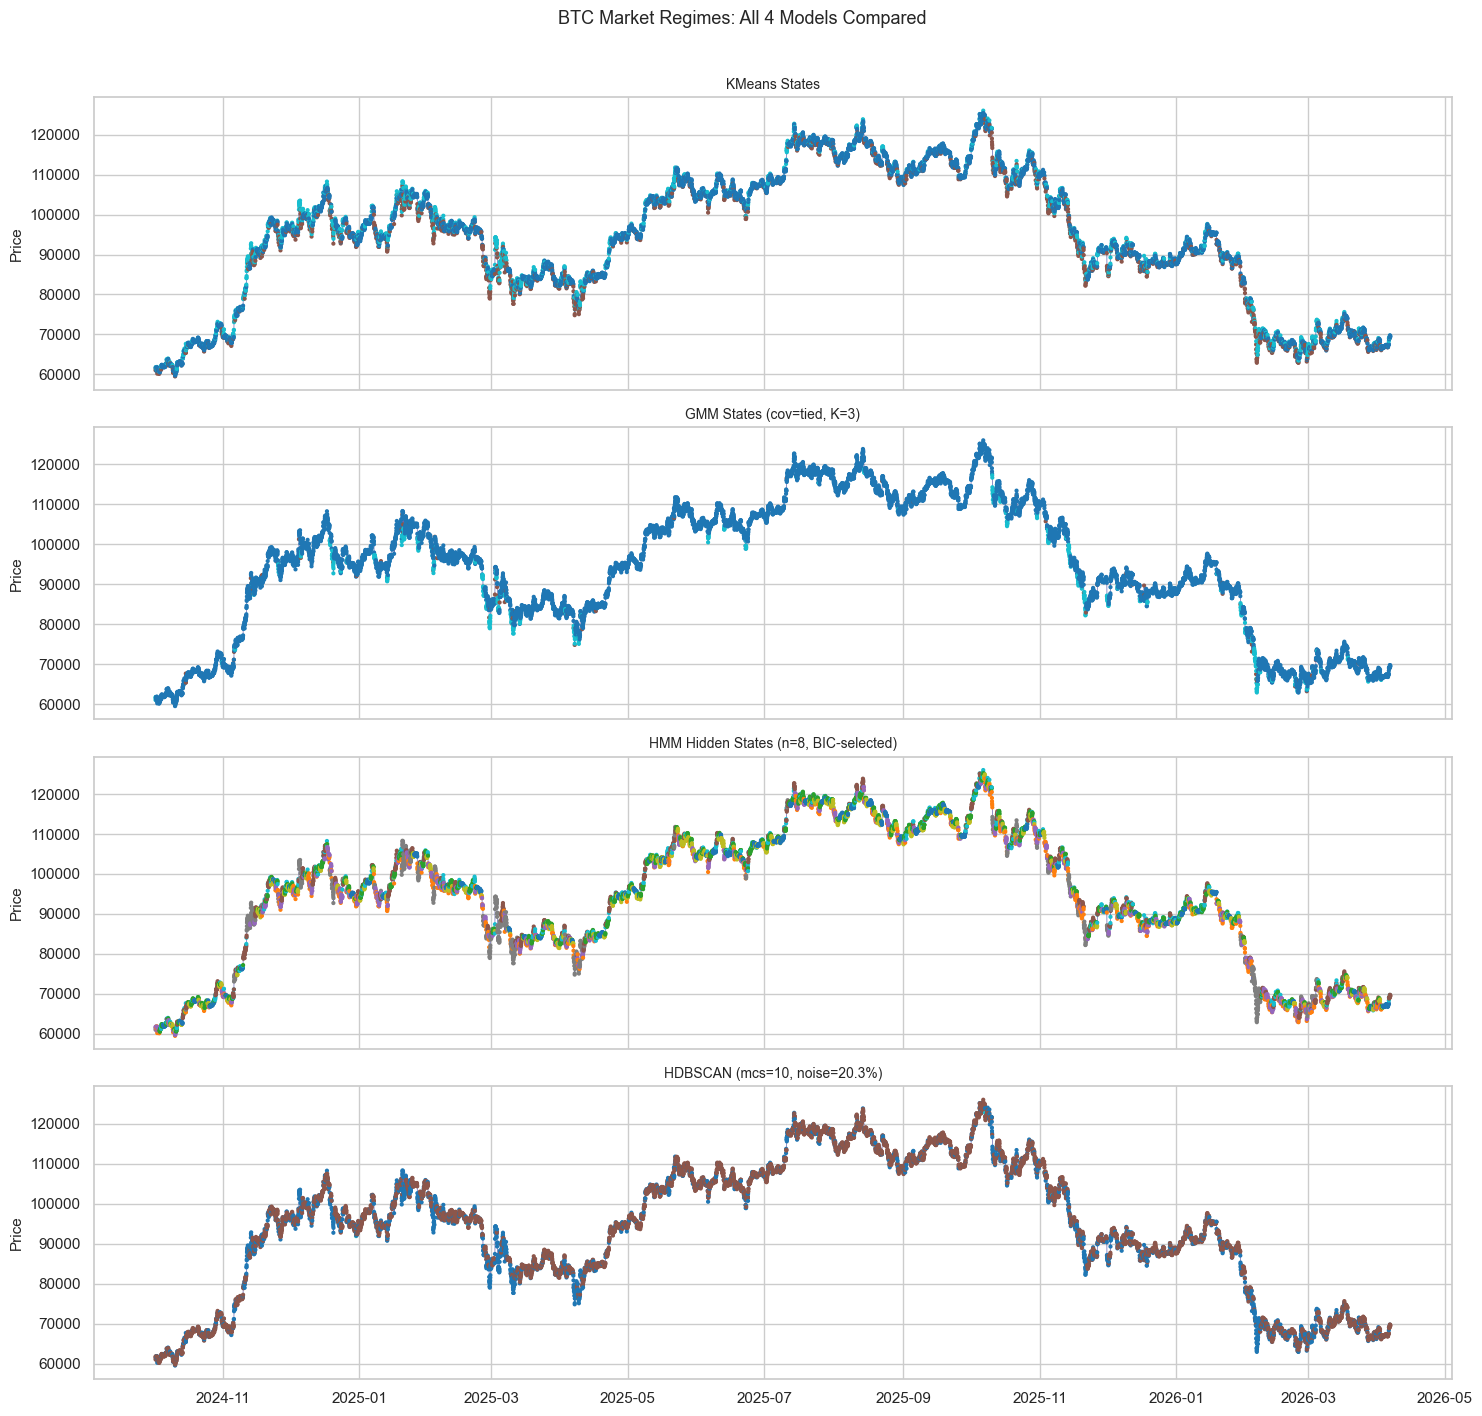

In [25]:
# ── XVI.2: Final visualization — all models price overlay ────────────────────
fig, axes = plt.subplots(4,1,figsize=(15,14),sharex=True)
price = df['close']
cmaps = ['tab10','tab10','tab10','RdYlBu']
state_cols = ['state_km','state_gmm','state_hmm','state_hdb']
titles = [
    'KMeans States',
    f'GMM States (cov={best_gmm_row["cov"]}, K={best_gmm_row["k"]})',
    f'HMM Hidden States (n={hmm_n}, BIC-selected)',
    f'HDBSCAN (mcs={best_hdb["mcs"]}, noise={hdb_noise:.1%})'
]

for ax, col, title in zip(axes, state_cols, titles):
    ax.plot(df.index, price, lw=0.5, color='navy', alpha=0.6, zorder=2)
    sc = ax.scatter(df.index, price, c=df[col], cmap='tab10',
                    s=4, zorder=3, vmin=df[col].min(), vmax=df[col].max())
    ax.set_ylabel('Price')
    ax.set_title(title, fontsize=10)

plt.suptitle('BTC Market Regimes: All 4 Models Compared', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


#### Phân tích Tổng hợp cuối cùng:
- Khi tất cả các mô hình (GMM, HMM, HDBSCAN) cùng đồng thuận về một trạng thái, độ tin cậy của phân tích đạt mức cao nhất. 
- Đây là cơ sở khoa học để đưa ra quyết định thay đổi chiến lược giao dịch phù hợp với môi trường.
